# "50 startups."

### _"Predict which companies to invest for maximizing profit" (Regression task)._

The dataset that's we see here contains data about **50 startups**. It has **7 columns**: “ID”, “R&D Spend”, “Administration”, “Marketing Spend”, “State”, “Category” “Profit”.

#### _Метаданные_:  
**ID** - startup ID  
**R&D Spend** - how much each startup spends on Research and Development  
**Administration** - how much they spend on Administration cost  
**Marketing Spend** - how much they spend on Marketing  
**State** - which state the startup is based in  
**Category** - which business category the startup belong to  
**Profit** - the profit made by the startup  

#### _Questions_:  
Predict which companies to invest for maximizing profit (choose model with the best score; create predictions; choose companies)  

## Import, Load

In [277]:
# import standard libraries
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import pylab as pl
from scipy import stats                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

# import models and metrics
from sklearn import metrics, linear_model, model_selection
from sklearn.metrics import r2_score, mean_squared_error, mean_squared_log_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

In [278]:
# read data from '.csv' files
train = pd.read_csv("train.csv")
final_test = pd.read_csv("test.csv")

# identify target
target = train['Profit']

## EDA

In [279]:
# print the full summary of the Train dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               50 non-null     int64  
 1   R&D Spend        48 non-null     float64
 2   Administration   50 non-null     float64
 3   Marketing Spend  47 non-null     float64
 4   State            50 non-null     object 
 5   Category         49 non-null     object 
 6   Profit           50 non-null     float64
dtypes: float64(4), int64(1), object(2)
memory usage: 2.9+ KB


In [280]:
# print the full summary of the Test dataset
final_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               50 non-null     int64  
 1   R&D Spend        48 non-null     float64
 2   Administration   48 non-null     float64
 3   Marketing Spend  50 non-null     float64
 4   State            49 non-null     object 
 5   Category         50 non-null     object 
dtypes: float64(3), int64(1), object(2)
memory usage: 2.5+ KB


In [281]:
# preview of the first 5 lines of the loaded Train data 
train.head()

,ID,R&D Spend,Administration,Marketing Spend,State,Category,Profit
0,0,165349.20,136897.80,471784.10,New York,Industrials,192261.83
1,1,162597.70,151377.59,443898.53,California,Technology,191792.06
2,2,153441.51,101145.55,407934.54,Florida,Healthcare,191050.39
3,3,144372.41,118671.85,383199.62,New York,Financials,182901.99
4,4,142107.34,91391.77,366168.42,Florida,Industrials,166187.94


In [282]:
# preview of the first 5 lines of the loaded Test data 
final_test.head()

,ID,R&D Spend,Administration,Marketing Spend,State,Category
0,0,165349.20,136897.80,471784.10,New York,Industrials
1,1,162597.70,151377.59,443898.53,California,Technology
2,2,153441.51,101145.55,407934.54,Florida,Healthcare
3,3,144372.41,118671.85,383199.62,New York,Financials
4,4,142107.34,91391.77,366168.42,Florida,Industrials


## Observation of target variable

In [283]:
# target variable
train['Profit'].describe()

count        50.000000
mean     112012.639200
std       40306.180338
min       14681.400000
25%       90138.902500
50%      107978.190000
75%      139765.977500
max      192261.830000
Name: Profit, dtype: float64

<Axes: xlabel='Profit', ylabel='Count'>

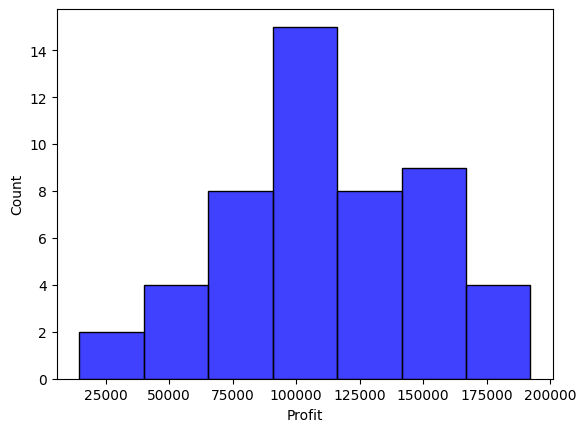

In [284]:
# visualisation of 'Profit' distribution
sns.histplot(train['Profit'], color='b')

In [285]:
# set 'ID' to index
train = train.set_index('ID')
final_test = final_test.set_index('ID')

## Numerical and Categorical features
#### List of Numerical and Categorical features

In [286]:
# check for Numerical and Categorical features in Train
numerical_feats_train = train.dtypes[train.dtypes != 'object'].index
print ('Quantity of Numerical features: ', len(numerical_feats_train))
print ()
print (train[numerical_feats_train].columns)
print ()
categorical_feats_train = train.dtypes[train.dtypes == 'object'].index
print ('Quantity of Categorical features: ', len(categorical_feats_train))
print ()
print (train[categorical_feats_train].columns)

Quantity of Numerical features:  4

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit'], dtype='object')

Quantity of Categorical features:  2

Index(['State', 'Category'], dtype='object')


In [287]:
train.Category.value_counts()


Category
Technology            22
Healthcare            11
Financials             6
Industrials            5
Telecommunications     4
Oil & Gas              1
Name: count, dtype: int64

## Missing values

#### List of data features with missing values

In [288]:
# check the Train features with missing values 
nan_columns = [i for i in train.columns if train[i].isnull().any()]
print(train.isnull().sum())
print()
print("There are " + str(len(nan_columns)) +" columns with NAN values for 50 rows.")
nan_columns

R&D Spend          2
Administration     0
Marketing Spend    3
State              0
Category           1
Profit             0
dtype: int64

There are 3 columns with NAN values for 50 rows.


['R&D Spend', 'Marketing Spend', 'Category']

In [289]:
# check the Test features with missing values
nan_columns_final = [i for i in final_test.columns if final_test[i].isnull().any()]
print(final_test.isnull().sum())
print()
print("There are " + str(len(nan_columns_final)) +" columns with NAN values for 50 rows.")
nan_columns.append('Marketing Spend')  # adding 'Marketing Spend' from Test set
nan_columns

R&D Spend          2
Administration     2
Marketing Spend    0
State              1
Category           0
dtype: int64

There are 3 columns with NAN values for 50 rows.


['R&D Spend', 'Marketing Spend', 'Category', 'Marketing Spend']

#### Filling missing values

Fields where NAN values have meaning.

Explaining in further depth:

* 'R&D Spend': Numerical - replacement of NAN by 'mean';
* 'Administration': Numerical - replacement of NAN by 'mean';
* 'Marketing Spend': Numerical - replacement of NAN by 'mean';
* 'State': Categorical - replacement of NAN by 'None';
* 'Category': Categorical - replacement of NAN by 'None'.

In [290]:
nan_columns_fill = [
    'State', 
    'Category'
    ]
for col in nan_columns_fill:
    if train[col].dtype == 'object':  # или np.object_
        train.fillna({col: 'None'}, inplace=True)
        final_test.fillna({col: 'None'}, inplace=True)
    else:
        print(f'Внимание: {col} не строковый, а {train[col].dtype}')



In [291]:
# Числовые столбцы — заполним средним
for col in ['R&D Spend', 'Administration', 'Marketing Spend']:
    mean_value = train[col].mean()
    train.loc[:, col] = train[col].fillna(mean_value)
    final_test[col] = final_test[col].fillna(mean_value)

In [292]:
# check is there any mising values left in Train
train.isnull().sum().sum()

np.int64(0)

In [293]:
final_test.shape

(50, 5)

In [294]:
final_test.isnull().sum().sum()

np.int64(0)

### Visualisation  of Numerical features (regplot)

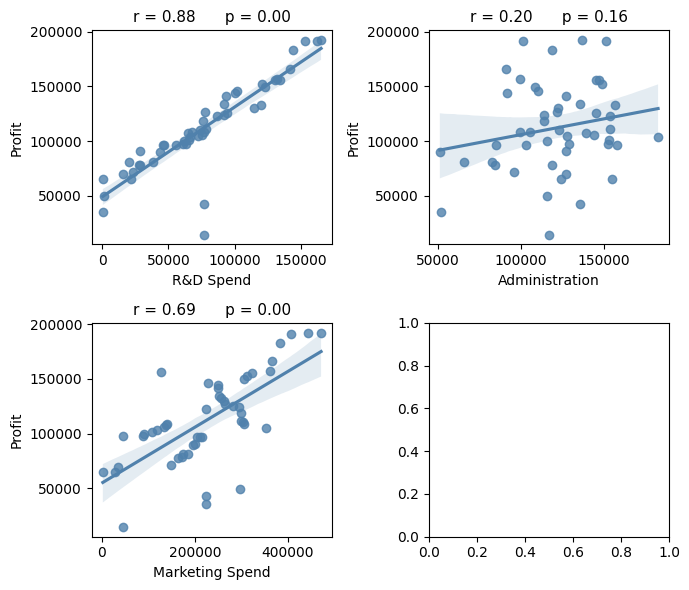

In [295]:
# numerical features visualisation
nr_rows = 2
nr_cols = 2

fig, axs = plt.subplots(nr_rows, nr_cols, figsize=(nr_cols*3.5,nr_rows*3))

num_feats = list(numerical_feats_train)
not_plot = ['Id',  'Profit']
plot_num_feats = [c for c in list(numerical_feats_train) if c not in not_plot]


for r in range(0,nr_rows):
    for c in range(0,nr_cols):  
        i = r*nr_cols + c
        if i < len(plot_num_feats):
            sns.regplot(x=train[plot_num_feats[i]], y=train['Profit'], ax = axs[r][c], color = "#5081ac" )
            stp = stats.pearsonr(train[plot_num_feats[i]], train['Profit'])
          
            str_title = "r = " + "{0:.2f}".format(stp[0]) + "      " "p = " + "{0:.2f}".format(stp[1])
            axs[r][c].set_title(str_title, fontsize=11)



plt.tight_layout()    
plt.show()

C:\Users\mamon\AppData\Local\Temp\ipykernel_2576\1998211702.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'State', y = 'Profit', data = train, palette = "Blues_d", legend=False)


<Axes: xlabel='State', ylabel='Profit'>

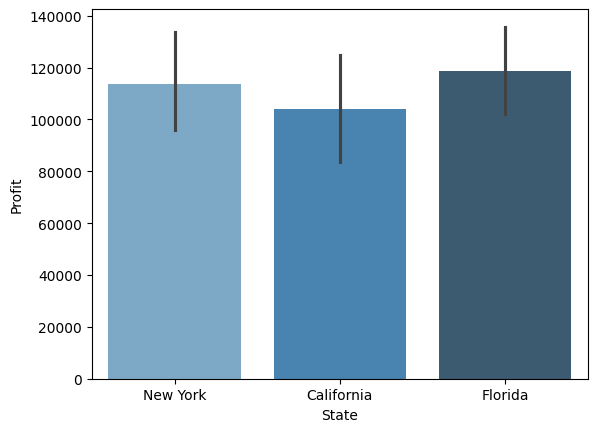

In [296]:
# profit split in State level
sns.barplot(x = 'State', y = 'Profit', data = train, palette = "Blues_d", legend=False)

C:\Users\mamon\AppData\Local\Temp\ipykernel_2576\340480087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Category', y = 'Profit', data = train, palette = "Blues_d")


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Industrials'),
  Text(1, 0, 'Technology'),
  Text(2, 0, 'Healthcare'),
  Text(3, 0, 'Financials'),
  Text(4, 0, 'Telecommunications'),
  Text(5, 0, 'None'),
  Text(6, 0, 'Oil & Gas')])

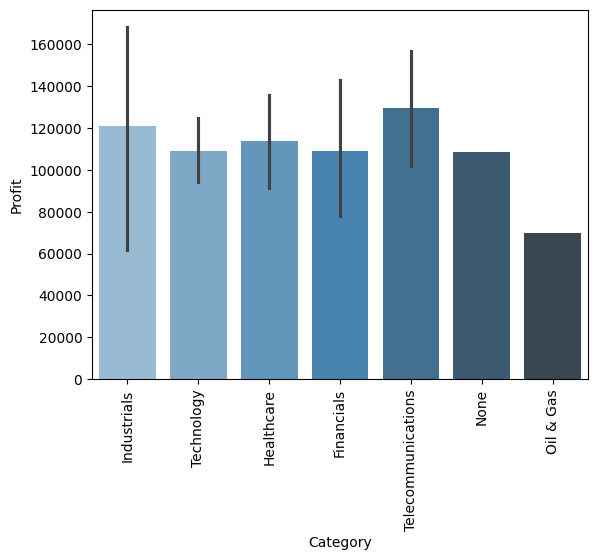

In [297]:
# profit split in State level
sns.barplot(x = 'Category', y = 'Profit', data = train, palette = "Blues_d")
plt.xticks(rotation=90)

## One-Hot Encoding

In [298]:
# One-Hot Encoding Train dataset

train = pd.get_dummies(train,columns=['State', 'Category'])
target = train['Profit']

# Drop target variable 
train = train.drop(columns=['Profit'])


In [299]:
# preview of the first 5 lines of the loaded Train data 
train.head()

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York,Category_Financials,Category_Healthcare,Category_Industrials,Category_None,Category_Oil & Gas,Category_Technology,Category_Telecommunications
ID,,,,,,,,,,,,,
0,165349.20,136897.80,471784.10,False,False,True,False,False,True,False,False,False,False
1,162597.70,151377.59,443898.53,True,False,False,False,False,False,False,False,True,False
2,153441.51,101145.55,407934.54,False,True,False,False,True,False,False,False,False,False
3,144372.41,118671.85,383199.62,False,False,True,True,False,False,False,False,False,False
4,142107.34,91391.77,366168.42,False,True,False,False,False,True,False,False,False,False


In [300]:
# Drop unnecessary variables 
train = train.drop(columns=['Category_None'])

In [301]:
# One Hot-Encoding Test dataset
train.shape

(50, 12)

In [302]:
# One-Hot Encoding Test dataset
final_test = pd.get_dummies(final_test,columns=['State', 'Category'])
final_test.head(50)

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York,State_None,Category_Financials,Category_Healthcare,Category_Industrials,Category_Oil & Gas,Category_Technology,Category_Telecommunications
ID,,,,,,,,,,,,,
0,165349.200000,136897.8000,471784.10,False,False,True,False,False,False,True,False,False,False
1,162597.700000,151377.5900,443898.53,True,False,False,False,False,False,False,False,True,False
2,153441.510000,101145.5500,407934.54,False,True,False,False,False,True,False,False,False,False
3,144372.410000,118671.8500,383199.62,False,False,True,False,True,False,False,False,False,False
4,142107.340000,91391.7700,366168.42,False,True,False,False,False,False,True,False,False,False
5,131876.900000,99814.7100,362861.36,False,False,True,False,False,False,False,False,False,True
6,134615.460000,147198.8700,127716.82,True,False,False,False,False,False,False,False,False,True
7,130298.130000,145530.0600,323876.68,False,True,False,False,False,False,False,False,True,False
8,120542.520000,148718.9500,311613.29,False,False,True,False,False,True,False,False,False,False


In [303]:
final_test = final_test.drop(columns=['State_None'])

### 'Train\Test' split

In [304]:
from sklearn.model_selection import train_test_split

In [305]:
X_train, X_test, y_train, y_test = train_test_split(train, target, test_size=0.30, random_state=27)

In [306]:
X_train.shape

(35, 12)

## StandardScaler

In [307]:
# Standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train)
test_scaled = scaler.transform(X_test)


## Two models probation  **LR** and **GB**

### **Linear Regression**

In [308]:
# Linear Regression model
LR = LinearRegression()

# Model Training
LR.fit(train_scaled,y_train)

# Model Prediction
LR_pred = LR.predict(test_scaled)
LR_pred

array([149508.7717395 , 110626.18460399,  85790.61221051,  54518.96923537,
       140508.88970539, 146347.9852258 , 121193.65975156, 120442.20778232,
       104208.28704842,  79079.18228512, 117953.93847876,  46200.16756101,
       180478.91354496, 132438.30551055, 128857.5093249 ])

In [309]:
# Model R2 score

LRscore = LR.score(test_scaled, y_test)
LRscore

0.8139762119179693

In [310]:
# Model Metrics
LRMetrics = pd.DataFrame({'Model': 'Linear Regression',
                          'r2score':r2_score(y_test,LR_pred),
                          'MAE': metrics.mean_absolute_error (y_test,LR_pred),
                          'MSE': metrics.mean_squared_error(y_test,LR_pred),
                          'RMSE': np.sqrt(metrics.mean_squared_error(y_test,LR_pred)),
                          'MSLE': metrics.mean_squared_log_error(y_test,LR_pred),
                          'RMSLE':np.sqrt(metrics.mean_squared_log_error(y_test,LR_pred))             
                          },index=[1])

LRMetrics

,Model,r2score,MAE,MSE,RMSE,MSLE,RMSLE
1,Linear Regression,0.813976,12969.221515,2.544529e+08,15951.579675,0.039393,0.198477


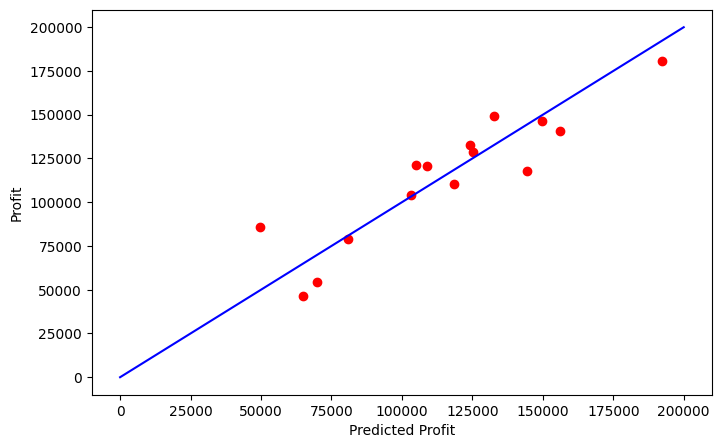

In [311]:
# visualisation of Train dataset predictions

# Plot outputs
plt.figure(figsize=(8,5))
pl.plot(y_test, LR_pred,'ro')
pl.plot([0,200000],[0,200000],'b-')
pl.xlabel('Predicted Profit')
pl.ylabel('Profit')
pl.show()

In [312]:
# Test final predictions
y = target

LR_pred1 = LR.predict(final_test)
LR_pred1  

c:\Users\mamon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([9.79584814e+09, 9.45494552e+09, 8.68218077e+09, 8.22806446e+09,
       7.90380776e+09, 7.63585802e+09, 5.19652366e+09, 7.28725681e+09,
       6.91583123e+09, 6.79830848e+09, 5.44959118e+09, 5.56681180e+09,
       5.49836426e+09, 5.50650445e+09, 6.30416166e+09, 6.13310740e+09,
       5.25089866e+09, 5.93559589e+09, 5.91506402e+09, 5.37556204e+09,
       5.57079773e+09, 5.74810759e+09, 5.59193011e+09, 5.39960239e+09,
       3.77417592e+09, 3.55006335e+09, 3.78427902e+09, 6.11922806e+09,
       3.48313665e+09, 3.26519563e+09, 2.89055464e+09, 2.94062512e+09,
       2.45803006e+09, 4.08039689e+09, 3.96526387e+09, 3.69158936e+09,
       3.32873667e+09, 3.64989996e+09, 2.76910380e+09, 3.15761796e+09,
       4.99216371e+09, 2.77894101e+09, 2.52047251e+09, 1.14278969e+09,
       1.30496415e+09, 3.95234507e+08, 3.69477485e+09, 4.25360684e+09,
       1.13280579e+09, 2.74634247e+09])

In [313]:
# Model Metrics
LRMetrics1 = pd.DataFrame({'Model': 'Linear Regression',
                           'r2score':r2_score(y,LR_pred1),
                           'MAE': metrics.mean_absolute_error (y,LR_pred1),
                           'MSE': metrics.mean_squared_error(y,LR_pred1),
                           'RMSE': np.sqrt(metrics.mean_squared_error(y,LR_pred1)),
                           'MSLE': metrics.mean_squared_log_error(y,LR_pred1),
                           'RMSLE':np.sqrt(metrics.mean_squared_log_error(y,LR_pred1))             
                           },index=[1])

LRMetrics1

,Model,r2score,MAE,MSE,RMSE,MSLE,RMSLE
1,Linear Regression,-1.718887e+10,4.780182e+09,2.736633e+19,5.231284e+09,112.79704,10.620595


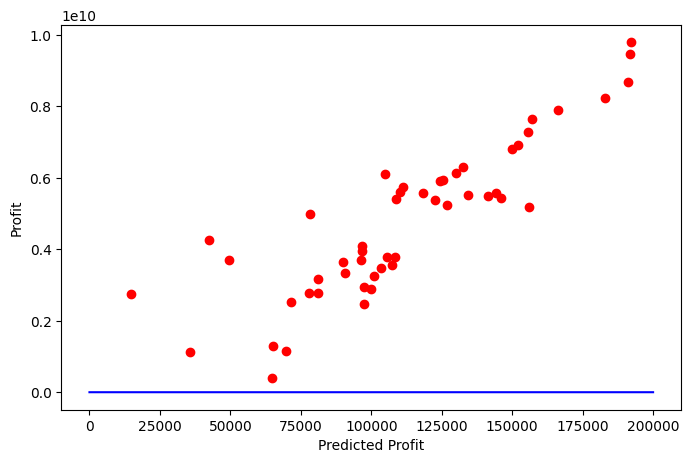

In [314]:
# visualisation of Test dataset predictions

# Plot outputs
plt.figure(figsize=(8,5))
pl.plot(y, LR_pred1,'ro')
pl.plot([0,200000],[0,200000],'b-')
pl.xlabel('Predicted Profit')
pl.ylabel('Profit')
pl.show()

In [315]:
# comparison between Actual 'Profit' from Train dataset abd Predicted 'Profit' from Test dataset
actualvspredicted = pd.DataFrame({"Actual Profit":y,"LR Predicted Profit":LR_pred1 })
actualvspredicted.head(10).style.background_gradient(cmap='Blues')

,Actual Profit,LR Predicted Profit
ID,,
0,192261.830000,9795848136.044573
1,191792.060000,9454945515.343065
2,191050.390000,8682180773.862715
3,182901.990000,8228064456.693401
4,166187.940000,7903807763.435506
5,156991.120000,7635858024.831015
6,156122.510000,5196523661.123989
7,155752.600000,7287256809.007368
8,152211.770000,6915831225.795016


### **Gradient Boosting Regressor**

In [316]:
# Gradient Boosting Regressor model
GB=GradientBoostingRegressor(random_state=27)

# Model Training
GB.fit(train_scaled,y_train)

# Model Prediction
GB_pred = GB.predict(test_scaled)

# Model R2 score
GBscore =GB.score(test_scaled, y_test)

In [317]:
# Model Metrics
GBMetrics = pd.DataFrame({'Model': 'Gradient Boosting Regressor',
                          'r2score':r2_score(y_test,GB_pred),
                          'MAE': metrics.mean_absolute_error (y_test,GB_pred),
                          'MSE': metrics.mean_squared_error(y_test,GB_pred),
                          'RMSE': np.sqrt(metrics.mean_squared_error(y_test,GB_pred)),
                          'MSLE': metrics.mean_squared_log_error(y_test,GB_pred),
                          'RMSLE':np.sqrt(metrics.mean_squared_log_error(y_test,GB_pred))             
                          },index=[2])

GBMetrics

,Model,r2score,MAE,MSE,RMSE,MSLE,RMSLE
2,Gradient Boosting Regressor,0.793628,11007.154299,2.822856e+08,16801.358471,0.042612,0.206427


ValueError: x and y must have same first dimension, but have shapes (50,) and (15,)

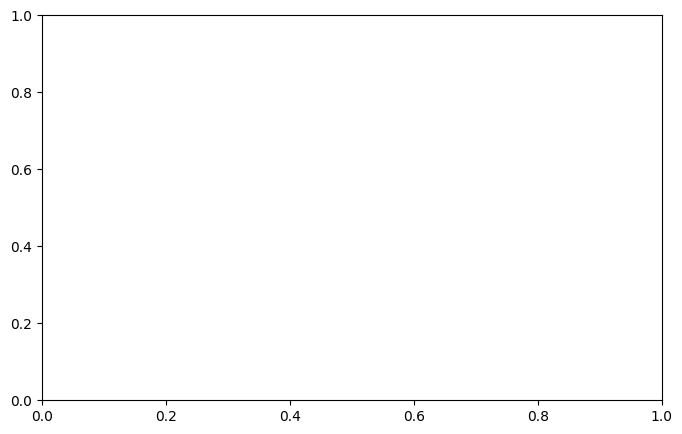

In [318]:
# visualisation of Test dataset predictions

# Plot outputs
plt.figure(figsize=(8,5))
pl.plot(y, GB_pred,'ro')
pl.plot([0,200000],[0,200000], 'b-')
pl.xlabel('Predicted Profit')
pl.ylabel('Profit')
pl.show()

In [ ]:
# Test final predictions
GB_pred1 = GB.predict(final_test)

In [ ]:
# Model Metrics
GBMetrics1 = pd.DataFrame({'Model': 'GradientBoostingRegressor',
                           'r2score':r2_score(y,GB_pred1),
                           'MAE': metrics.mean_absolute_error (y,GB_pred1),
                           'MSE': metrics.mean_squared_error(y,GB_pred1),
                           'RMSE': np.sqrt(metrics.mean_squared_error(y,GB_pred1)),
                           'MSLE': metrics.mean_squared_log_error(y,GB_pred1),
                           'RMSLE':np.sqrt(metrics.mean_squared_log_error(y,GB_pred1))             
                          },index=[1])

GBMetrics1

,Model,r2score,MAE,MSE,RMSE,MSLE,RMSLE
1,GradientBoostingRegressor,0.971998,3540.453047,4.458144e+07,6676.933609,0.007985,0.089359


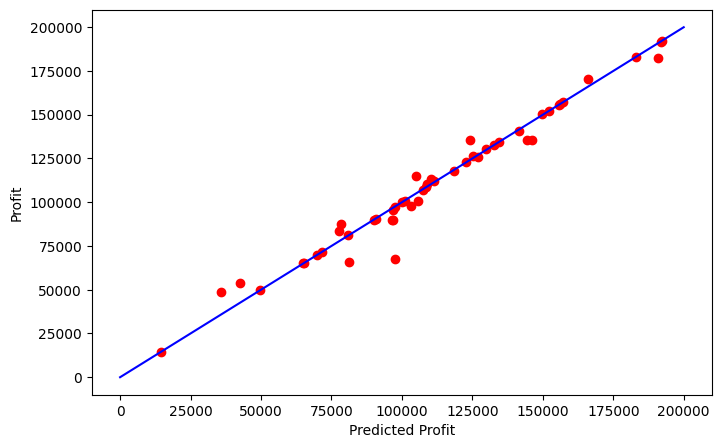

In [ ]:
# visualisation of Test dataset predictions

# Plot outputs
plt.figure(figsize=(8,5))
pl.plot(y, GB_pred1,'ro')
pl.plot([0,200000],[0,200000], 'b-')
pl.xlabel('Predicted Profit')
pl.ylabel('Profit')
pl.show()

## Model comparison

In [ ]:
# score comparison of models
frames = [LRMetrics1,GBMetrics1]
TrainingResult = pd.concat(frames)
TrainingResult

,Model,r2score,MAE,MSE,RMSE,MSLE,RMSLE
1,Linear Regression,0.826794,11451.483704,2.757611e+08,16606.056894,0.077758,0.278850
1,GradientBoostingRegressor,0.971998,3540.453047,4.458144e+07,6676.933609,0.007985,0.089359


In [ ]:
# comparison between Actual 'Profit' from Train dataset abd Predicted 'Profit' from Test dataset
actualvspredicted = pd.DataFrame({"Actual Profit":y,"LR Predicted Profit":LR_pred1, "GB Predicted Profit":GB_pred1})
actualvspredicted.head(20).style.background_gradient(cmap='Blues')

,Actual Profit,LR Predicted Profit,GB Predicted Profit
0,192261.830000,173426.181017,191867.624129
1,191792.060000,189136.035557,191631.052384
2,191050.390000,188946.035741,182312.330201
3,182901.990000,172036.552176,182851.070198
4,166187.940000,142782.308756,170184.031177
5,156991.120000,167404.746140,156991.181748
6,156122.510000,149507.668697,156065.183378
7,155752.600000,157587.392262,155657.315655
8,152211.770000,161999.462058,152090.773106
9,149759.960000,156553.515380,150395.829435


**Result**: The best model is **Gradient Boosting Regressor** with **R2 score = 0.972002**.

##  Save results:

In [ ]:
# submission of .csv file with final predictions
sub = pd.DataFrame()
sub['ID'] = final_test.index
sub['Profit'] = GB_pred1
sub.to_csv('StartupPredictions.csv', index=False)

## What else we can do?

Check multicoleniarity  
P-value  
t-test
